<a href="https://colab.research.google.com/github/Moukthika-y/Foundations-of-Data-Science-Lab/blob/main/FDS_06_07_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# (a) Read the Dataset
df = pd.read_csv("Automobile_data.csv")

print("First 5 entries")
print(df.head())

print("Data set shape")
print(df.shape)

print("Column names")
print(df.columns)

print("\nData types")
print(df.dtypes)

print("\nMissing values")
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

First 5 entries
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel-system  bore  stroke compr

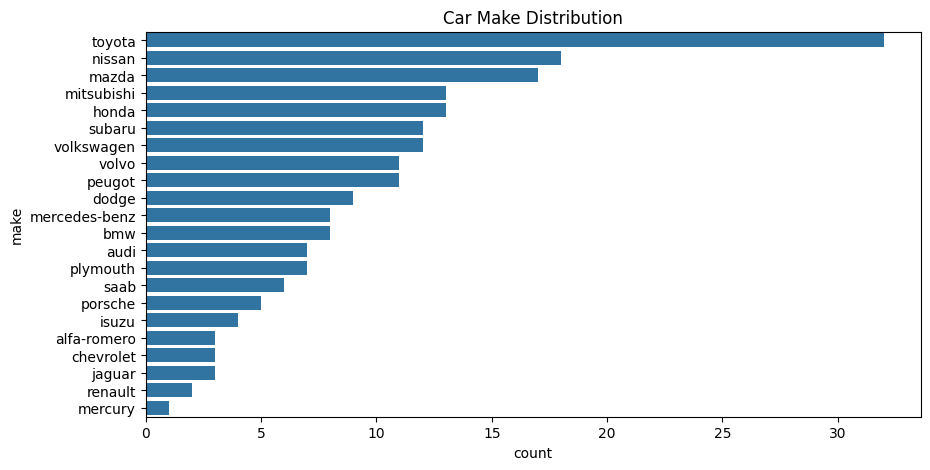

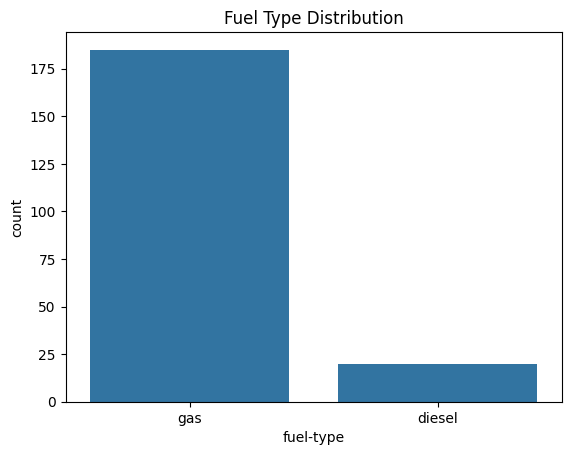

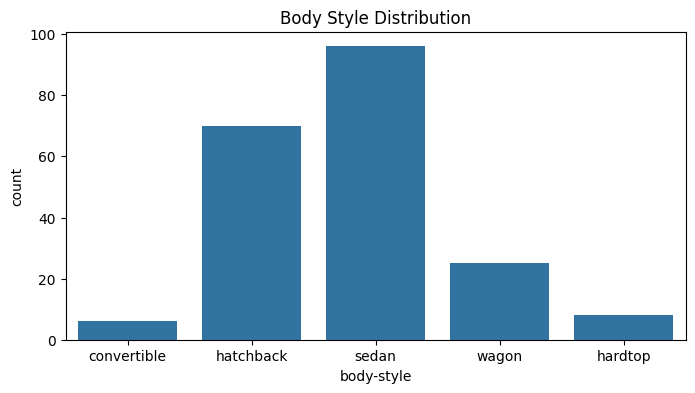

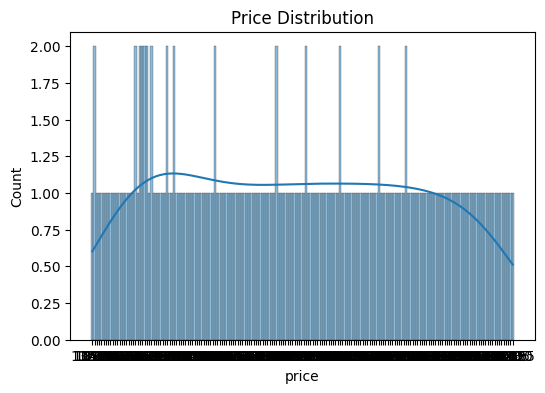

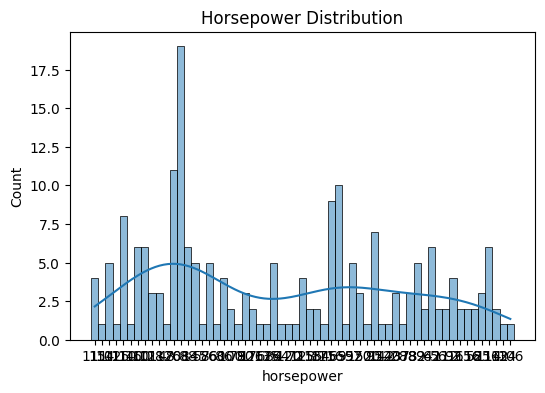

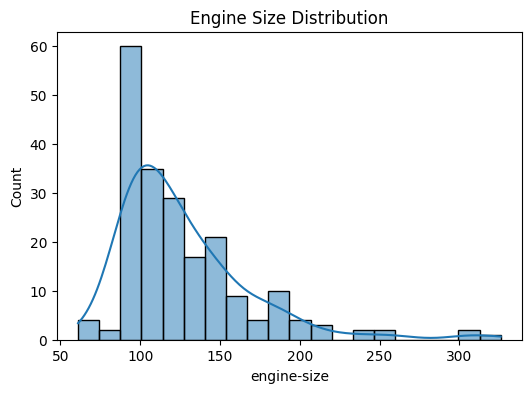

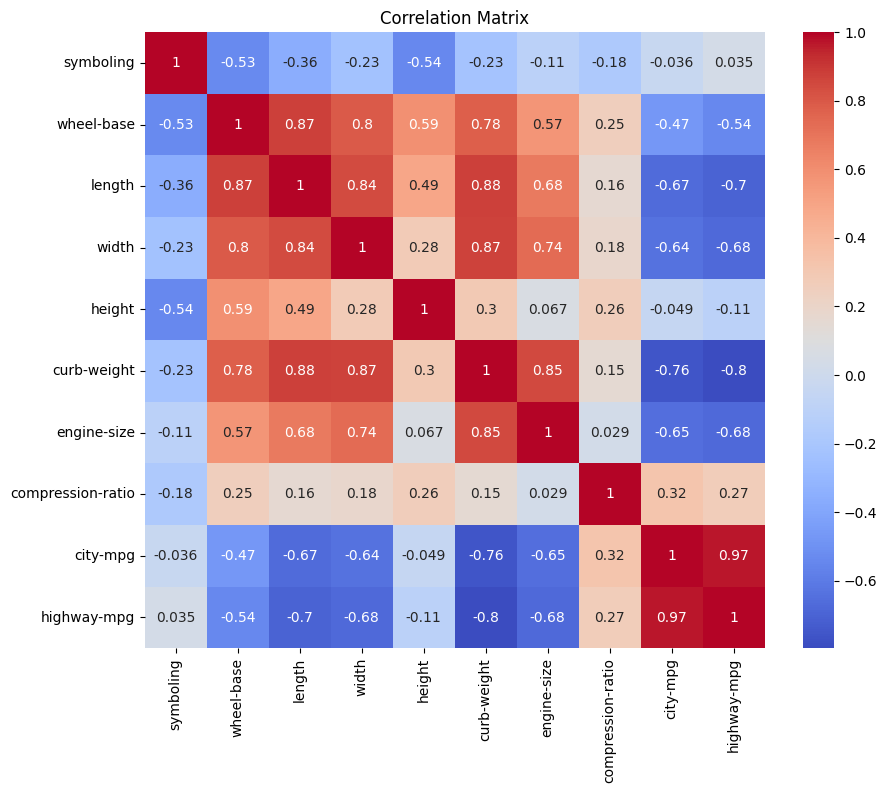

In [3]:
# Exploratory Data Analysis (EDA)

# Car Make Distribution
plt.figure(figsize=(10,5))
sns.countplot(y='make', data=df,
              order=df['make'].value_counts().index)
plt.title("Car Make Distribution")
plt.show()

# Fuel Type Distribution
sns.countplot(x='fuel-type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

# Body Style Distribution
plt.figure(figsize=(8,4))
sns.countplot(x='body-style', data=df)
plt.title("Body Style Distribution")
plt.show()

# Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['price'].dropna(), bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

# Horsepower Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['horsepower'].dropna(), bins=20, kde=True)
plt.title("Horsepower Distribution")
plt.show()

# Engine Size Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['engine-size'], bins=20, kde=True)
plt.title("Engine Size Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [4]:
# Identify Attributes

print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64','float64']).columns
print(list(numeric))

print("\nNominal Attributes")
nominal = df.select_dtypes(include=['object']).columns
print(list(nominal))

print("\nBinary Attributes")
binary = []

for col in df.columns:
    if df[col].nunique(dropna=True) == 2:
        binary.append(col)

print(binary)


Numeric Attributes
['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'compression-ratio', 'city-mpg', 'highway-mpg']

Nominal Attributes
['normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']

Binary Attributes
['fuel-type', 'aspiration', 'num-of-doors', 'engine-location']


In [5]:
# Nominal Attribute Dissimilarity
fuel = df['fuel-type']
body = df['body-style']

count = 0
total = 0

for f, b in zip(fuel, body):

    if pd.isna(f) or pd.isna(b):
        continue

    total += 1

    if f != b:
        count += 1

dissimilarity = count / total

print("\nNominal Attribute Dissimilarity")
print("Fuel Type vs Body Style =", dissimilarity)

similarity = 1 - dissimilarity

print("Nominal Attribute Similarity =", similarity)


Nominal Attribute Dissimilarity
Fuel Type vs Body Style = 1.0
Nominal Attribute Similarity = 0.0


In [6]:
# Numeric Attribute Dissimilarity
temp = df[['engine-size', 'city-mpg']].dropna()

engine1 = temp.iloc[0]['engine-size']
mpg1 = temp.iloc[0]['city-mpg']

engine2 = temp.iloc[1]['engine-size']
mpg2 = temp.iloc[1]['city-mpg']

distance = np.sqrt((engine1 - engine2)**2 +
                   (mpg1 - mpg2)**2)

print("\nEuclidean Distance")
print(distance)


Euclidean Distance
0.0
